# Task 2 - Predictive Maintenance

### Objective
Predict whether an asset is likely to experience a fault within the **next 24 hours**, so operations teams can plan maintenance before failure.

### Modeling approach
**Telemetry → Future-failure target → Metadata → Time-series features → Missing-value handling → Time split → Baseline → Random Forest → XGBoost → CatBoost → Threshold selection → Feature importance → Error analysis → Business insights**

> **Important:** The raw `fault_flag` is a current/historical fault indicator. It is **not** the prediction target. The target `failure_next_24h` is engineered from future fault events.


## 01. Load Data

We load:
- `sensor_telemetry.csv` — time-series sensor readings
- `asset_metadata.csv` — asset type, manufacturer, capacity, installation date, etc.

The telemetry is sorted by asset and timestamp because this is a time-series prediction problem.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

# Supports both:
#   project/notebooks/02_predictive_maintenance_final.ipynb
# and
#   project/02_predictive_maintenance_final.ipynb
possible_dirs = [
    Path("../data/raw"),
    Path("data/raw"),
    Path(".")
]

DATA_DIR = next(
    (p for p in possible_dirs if (p / "sensor_telemetry.csv").exists()),
    None
)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find sensor_telemetry.csv. "
        "Place the files in data/raw/."
    )

telemetry = pd.read_csv(DATA_DIR / "sensor_telemetry.csv")
metadata = pd.read_csv(DATA_DIR / "asset_metadata.csv")

telemetry["timestamp"] = pd.to_datetime(telemetry["timestamp"])
metadata["installation_date"] = pd.to_datetime(metadata["installation_date"])

telemetry = telemetry.sort_values(["asset_id", "timestamp"]).reset_index(drop=True)

print("Telemetry shape:", telemetry.shape)
print("Metadata shape :", metadata.shape)
print("Time range     :", telemetry["timestamp"].min(), "to", telemetry["timestamp"].max())

display(telemetry.head())
display(metadata.head())


Telemetry shape: (259200, 12)
Metadata shape : (30, 9)
Time range     : 2026-01-01 00:00:00 to 2026-03-31 23:45:00


,timestamp,site_id,building_id,asset_id,temperature,humidity,pressure,vibration,power_consumption,occupancy_count,operating_mode,fault_flag
0,2026-01-01 00:00:00,SITE_01,BLDG_01,ASSET_001,18.621,54.498,1.521,0.222,8.971,31,Idle,0
1,2026-01-01 00:15:00,SITE_01,BLDG_01,ASSET_001,19.923,47.778,1.505,0.191,8.939,43,Idle,0
2,2026-01-01 00:30:00,SITE_01,BLDG_01,ASSET_001,19.225,53.328,1.386,0.150,7.824,35,Idle,0
3,2026-01-01 00:45:00,SITE_01,BLDG_01,ASSET_001,19.856,56.998,1.528,0.206,54.215,40,Cooling,0
4,2026-01-01 01:00:00,SITE_01,BLDG_01,ASSET_001,19.841,54.713,1.549,0.181,43.278,25,Cooling,0


,asset_id,site_id,building_id,asset_name,asset_type,manufacturer,installation_date,capacity,parent_asset_id
0,ASSET_001,SITE_01,BLDG_01,Chiller-01,Chiller,Carrier,2022-07-18,1000,NaN
1,ASSET_002,SITE_01,BLDG_01,AHU-01-1,AHU,Daikin,2023-06-27,200,ASSET_001
2,ASSET_003,SITE_01,BLDG_01,AHU-01-2,AHU,Trane,2022-05-23,150,ASSET_001
3,ASSET_004,SITE_01,BLDG_01,Pump-01,Pump,KSB,2024-11-05,100,ASSET_001
4,ASSET_005,SITE_01,BLDG_01,EnergyMeter-01,Energy Meter,ABB,2023-08-13,500,NaN


In [2]:
# Dashboard / artifact output location
# When this notebook is run from the Jupyter Notebook folder,
# ../outputs points to the project-level outputs folder.
OUTPUTS_DIR = (
    Path("../outputs")
    if Path("../outputs").exists()
    else Path("outputs")
)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

## 02. Define Prediction Target

### What are we predicting?

For a reading at time **t**:

> `failure_next_24h = 1` if the same asset has at least one fault in the following 24 hours; otherwise `0`.

The data frequency is 15 minutes:

**24 hours × 4 readings/hour = 96 future observations**

We use `shift(-1)` first, so the **current fault is not used to create the target**.

Rows where `fault_flag == 1` are removed from modeling because the asset is already in a fault state; maintenance prediction should be made while the asset is currently operating normally.

The final 24 hours of each asset cannot have a complete 24-hour future window, so those rows are excluded from training/evaluation.


In [3]:
HORIZON_STEPS = 96  # 24 hours × 4 readings/hour

# Future fault within the next 96 intervals, excluding the current row.
future_fault = (
    telemetry.groupby("asset_id")["fault_flag"]
    .transform(
        lambda s: s.shift(-1)
                  .iloc[::-1]
                  .rolling(HORIZON_STEPS, min_periods=1)
                  .max()
                  .iloc[::-1]
    )
)

telemetry["failure_next_24h"] = future_fault.fillna(0).astype(int)

# Mark rows where a complete 24-hour future window exists.
rows_from_end = telemetry.groupby("asset_id").cumcount(ascending=False)
telemetry["target_window_complete"] = rows_from_end >= HORIZON_STEPS

# Keep only rows suitable for proactive prediction.
model_df = telemetry[
    (telemetry["fault_flag"] == 0) &
    (telemetry["target_window_complete"])
].copy()

print("Rows available for modeling:", len(model_df))
print("Positive target rows:", int(model_df["failure_next_24h"].sum()))


Rows available for modeling: 256050
Positive target rows: 5112


## 03. Check Target Distribution

Predictive maintenance is normally an **imbalanced classification problem** because failures are much less frequent than normal operation.

Therefore, accuracy is not our main metric. We focus on:

- **Precision** — among alerts, how many are actual upcoming failures?
- **Recall** — among upcoming failures, how many did we detect?
- **F1** — balance between precision and recall
- **ROC-AUC** — ranking/separation ability across thresholds


,count,percentage
failure_next_24h,,
0,250938,98.0
1,5112,2.0


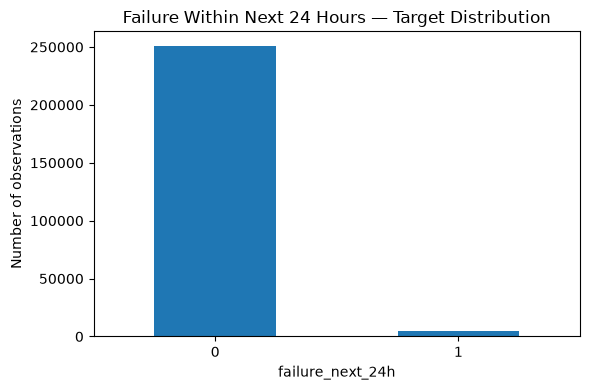

In [4]:
target_counts = model_df["failure_next_24h"].value_counts().sort_index()
target_pct = model_df["failure_next_24h"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_pct.round(2)
})
display(target_summary)

plt.figure(figsize=(6, 4))
target_summary["count"].plot(kind="bar")
plt.title("Failure Within Next 24 Hours — Target Distribution")
plt.xlabel("failure_next_24h")
plt.ylabel("Number of observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 04. Merge Asset Metadata

Telemetry tells us **what the asset is doing**. Metadata tells us **what the asset is**.

We merge:
- asset type
- manufacturer
- installation date
- capacity
- parent-asset information

From `installation_date`, we derive **asset age**, which is more useful for a model than the raw date.


In [5]:
metadata_cols = [
    "asset_id",
    "asset_type",
    "manufacturer",
    "installation_date",
    "capacity",
    "parent_asset_id"
]

model_df = model_df.merge(
    metadata[metadata_cols],
    on="asset_id",
    how="left",
    suffixes=("", "_meta")
)

model_df["asset_age_days"] = (
    model_df["timestamp"] - model_df["installation_date"]
).dt.days

model_df["asset_age_years"] = model_df["asset_age_days"] / 365.25

model_df["has_parent_asset"] = model_df["parent_asset_id"].notna().astype(int)

print("After metadata merge:", model_df.shape)
display(model_df[[
    "asset_id", "asset_type", "manufacturer",
    "capacity", "asset_age_years", "has_parent_asset"
]].head())


After metadata merge: (256050, 22)


,asset_id,asset_type,manufacturer,capacity,asset_age_years,has_parent_asset
0,ASSET_001,Chiller,Carrier,1000,3.457906,0
1,ASSET_001,Chiller,Carrier,1000,3.457906,0
2,ASSET_001,Chiller,Carrier,1000,3.457906,0
3,ASSET_001,Chiller,Carrier,1000,3.457906,0
4,ASSET_001,Chiller,Carrier,1000,3.457906,0


## 05. Feature Engineering

We create features from three sources:

### A. Current sensor condition
Temperature, humidity, pressure, vibration, power and occupancy.

### B. Historical behavior
Rolling statistics and recent changes are important because equipment degradation is often a **trend**, not a single reading.

Examples:
- vibration mean over previous 1h / 6h / 12h
- vibration maximum over previous 6h
- power mean over previous 6h
- recent change in vibration/power/temperature

### C. Time/context
Hour, day of week and weekend indicator.

**Leakage rule:** rolling features use `.shift(1)` before rolling, so the current/future observation is never included in the historical window.


In [6]:
# Time features
model_df["hour"] = model_df["timestamp"].dt.hour
model_df["day_of_week"] = model_df["timestamp"].dt.dayofweek
model_df["is_weekend"] = (model_df["day_of_week"] >= 5).astype(int)

# Create rolling features on the full ordered telemetry history.
# This ensures that a row only uses information available before that timestamp.
feature_source = telemetry.copy()
feature_source = feature_source.sort_values(["asset_id", "timestamp"]).reset_index(drop=True)

rolling_specs = {
    "vibration": [4, 24, 48],          # 1h, 6h, 12h
    "power_consumption": [4, 24, 48],
    "temperature": [4, 24],
    "pressure": [4, 24],
}

for col, windows in rolling_specs.items():
    shifted = feature_source.groupby("asset_id")[col].shift(1)

    for window in windows:
        suffix = {4: "1h", 24: "6h", 48: "12h"}[window]

        feature_source[f"{col}_mean_{suffix}"] = (
            shifted.groupby(feature_source["asset_id"])
            .transform(lambda x: x.rolling(window, min_periods=1).mean())
        )

        if col in ["vibration", "power_consumption"]:
            feature_source[f"{col}_max_{suffix}"] = (
                shifted.groupby(feature_source["asset_id"])
                .transform(lambda x: x.rolling(window, min_periods=1).max())
            )

# Recent changes using only historical values.
for col in ["vibration", "power_consumption", "temperature", "pressure"]:
    feature_source[f"{col}_change_1h"] = (
        feature_source[col] -
        feature_source.groupby("asset_id")[col].shift(4)
    )
    feature_source[f"{col}_change_6h"] = (
        feature_source[col] -
        feature_source.groupby("asset_id")[col].shift(24)
    )

engineered_cols = [
    c for c in feature_source.columns
    if c not in telemetry.columns
]

# Join engineered features back using the unique telemetry key.
feature_source_keyed = feature_source.set_index(["timestamp", "asset_id"])
model_df = model_df.set_index(["timestamp", "asset_id"])

model_df = model_df.join(
    feature_source_keyed[engineered_cols],
    how="left",
    rsuffix="_engineered"
).reset_index()

print("Modeling dataframe shape:", model_df.shape)
print("Number of engineered features:", len(engineered_cols))

display(model_df[[
    "timestamp", "asset_id",
    "vibration", "vibration_mean_6h", "vibration_max_6h",
    "vibration_change_6h",
    "power_consumption", "power_consumption_mean_6h",
    "power_consumption_change_6h",
    "failure_next_24h"
]].head())


Modeling dataframe shape: (256050, 49)
Number of engineered features: 24


,timestamp,asset_id,vibration,vibration_mean_6h,vibration_max_6h,vibration_change_6h,power_consumption,power_consumption_mean_6h,power_consumption_change_6h,failure_next_24h
0,2026-01-01 00:00:00,ASSET_001,0.222,NaN,NaN,NaN,8.971,NaN,NaN,0
1,2026-01-01 00:15:00,ASSET_001,0.191,0.222000,0.222,NaN,8.939,8.97100,NaN,0
2,2026-01-01 00:30:00,ASSET_001,0.150,0.206500,0.222,NaN,7.824,8.95500,NaN,0
3,2026-01-01 00:45:00,ASSET_001,0.206,0.187667,0.222,NaN,54.215,8.57800,NaN,0
4,2026-01-01 01:00:00,ASSET_001,0.181,0.192250,0.222,NaN,43.278,19.98725,NaN,0


## 06. Missing Value Handling

Sensor data can contain missing readings because of communication problems, sensor downtime or data-quality issues.

We use:
- **Median imputation** for numerical variables — robust to extreme values.
- **Most-frequent imputation** for categorical variables.
- Missing indicators for the original sensor columns so the model can learn whether missingness itself carries information.

The imputer is fitted **only on training data** through the preprocessing pipeline, preventing data leakage.


In [7]:
sensor_cols = [
    "temperature", "humidity", "pressure", "vibration",
    "power_consumption", "occupancy_count"
]

# Missingness indicators
for col in sensor_cols:
    model_df[f"{col}_missing"] = model_df[col].isna().astype(int)

target_col = "failure_next_24h"

numeric_features = [
    "temperature", "humidity", "pressure", "vibration",
    "power_consumption", "occupancy_count",
    "capacity", "asset_age_years", "has_parent_asset",
    "hour", "day_of_week", "is_weekend"
]

# Add engineered numeric features.
engineered_numeric = [
    c for c in model_df.columns
    if any(key in c for key in [
        "_mean_", "_max_", "_change_"
    ])
    and c not in numeric_features
]

missing_indicator_features = [f"{c}_missing" for c in sensor_cols]

numeric_features = list(dict.fromkeys(
    numeric_features + engineered_numeric + missing_indicator_features
))

categorical_features = [
    "site_id",
    "building_id",
    "operating_mode",
    "asset_type",
    "manufacturer"
]

# Ensure every requested feature exists.
numeric_features = [c for c in numeric_features if c in model_df.columns]
categorical_features = [c for c in categorical_features if c in model_df.columns]

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

display(model_df[numeric_features].isna().mean().sort_values(ascending=False).head(10))


Numeric features: 42
Categorical features: 5


temperature_change_6h    0.022328
temperature_change_1h    0.019969
vibration_change_6h      0.018442
pressure_change_6h       0.018125
vibration_change_1h      0.016165
pressure_change_1h       0.015817
humidity                 0.010295
temperature              0.009830
vibration                0.007870
pressure                 0.007713
dtype: float64

## 07. Time-Based Train / Validation / Test Split

Randomly splitting time-series data can leak future information into training.

Instead:

**Past → Train → Validation → Test → Future**

We also leave a **24-hour purge gap** at each boundary because the target itself looks 24 hours into the future. This prevents target windows from crossing between train/validation/test periods.


In [8]:
# Chronological cut points
unique_times = np.sort(model_df["timestamp"].unique())

train_cut = pd.Timestamp(unique_times[int(len(unique_times) * 0.60)])
val_cut = pd.Timestamp(unique_times[int(len(unique_times) * 0.80)])

PURGE = pd.Timedelta(hours=24)

train_mask = model_df["timestamp"] < (train_cut - PURGE)
val_mask = (
    (model_df["timestamp"] >= (train_cut + PURGE)) &
    (model_df["timestamp"] < (val_cut - PURGE))
)
test_mask = model_df["timestamp"] >= (val_cut + PURGE)

train_df = model_df.loc[train_mask].copy()
val_df = model_df.loc[val_mask].copy()
test_df = model_df.loc[test_mask].copy()

X_train, y_train = train_df[numeric_features + categorical_features], train_df[target_col]
X_val, y_val = val_df[numeric_features + categorical_features], val_df[target_col]
X_test, y_test = test_df[numeric_features + categorical_features], test_df[target_col]

print("Train:", train_df["timestamp"].min(), "→", train_df["timestamp"].max(), train_df.shape)
print("Valid:", val_df["timestamp"].min(), "→", val_df["timestamp"].max(), val_df.shape)
print("Test :", test_df["timestamp"].min(), "→", test_df["timestamp"].max(), test_df.shape)

split_summary = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "rows": [len(train_df), len(val_df), len(test_df)],
    "positive": [y_train.sum(), y_val.sum(), y_test.sum()],
    "positive_rate_%": [
        y_train.mean() * 100,
        y_val.mean() * 100,
        y_test.mean() * 100
    ]
})
display(split_summary.round(3))


Train: 2026-01-01 00:00:00 → 2026-02-22 09:15:00 (150740, 55)
Valid: 2026-02-24 09:30:00 → 2026-03-12 04:30:00 (45460, 55)
Test : 2026-03-14 04:45:00 → 2026-03-30 23:45:00 (48350, 55)


,split,rows,positive,positive_rate_%
0,Train,150740,3080,2.043
1,Validation,45460,932,2.050
2,Test,48350,768,1.588


## Common Preprocessing Pipeline

The same preprocessing is used for all models:

- Numerical → median imputation
- Categorical → most-frequent imputation + one-hot encoding

The preprocessing is fit only on training data.


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ],
    remainder="drop"
)


## 08. Baseline Model

Before using complex models, we need a simple reference point.

A `DummyClassifier` always predicts the majority class. Any useful predictive-maintenance model should provide substantially better failure detection than this baseline.


In [10]:
baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)
baseline_prob = baseline.predict_proba(X_test)[:, 1]

def evaluate_predictions(y_true, y_pred, y_prob, model_name, threshold=0.5):
    return {
        "model": model_name,
        "threshold": threshold,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        "average_precision": average_precision_score(y_true, y_prob)
    }

baseline_result = evaluate_predictions(
    y_test, baseline_pred, baseline_prob, "Dummy Baseline"
)

pd.DataFrame([baseline_result]).round(4)


,model,threshold,precision,recall,f1,roc_auc,average_precision
0,Dummy Baseline,0.5,0.0,0.0,0.0,0.5,0.0159


## 09. Tree-Based Models

We compare the successfully trained tree-based models:

- **Random Forest**
- **XGBoost**
- **CatBoost**

All three are tree-based ensemble methods, but they build trees differently.

> **Note:** LightGBM was attempted separately, but the local Windows environment produced a native-library access violation during `.fit()`. It is therefore not included in the final comparison.

For this predictive-maintenance problem, we evaluate them using:

- Precision
- Recall
- F1-score
- ROC-AUC

Because failure prediction is imbalanced, **accuracy is not used as the primary metric**.


In [11]:
# Install/import the requested boosting libraries if available.
# In a local environment, install missing packages with:
# pip install xgboost lightgbm catboost

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

print("Random Forest, XGBoost and CatBoost libraries imported successfully.")


Random Forest, XGBoost and CatBoost libraries imported successfully.


In [12]:
# Helper for consistent evaluation

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(name, model, X, y):
    pred = model.predict(X)
    prob = model.predict_proba(X)[:, 1]

    return {
        "model": name,
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "roc_auc": roc_auc_score(y, prob)
    }


### 09.1 Random Forest

Random Forest trains many decision trees on different samples of the training data and combines their predictions.

Why use it here:
- Captures nonlinear relationships.
- Handles interactions between sensor variables.
- Does not require feature scaling.
- Provides a useful tree-based baseline.


In [13]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_result = evaluate_model(
    "Random Forest",
    rf_model,
    X_test,
    y_test
)

rf_result

{'model': 'Random Forest',
 'precision': 0.153168044077135,
 'recall': 0.3619791666666667,
 'f1': 0.21525358110723963,
 'roc_auc': 0.6586382975486179}

### 09.2 XGBoost

XGBoost builds trees sequentially. Each new tree attempts to correct errors made by previous trees.

Why use it here:
- Strong performance on structured/tabular data.
- Captures nonlinear sensor interactions.
- Supports class weighting for imbalanced failures.
- Often performs well when relationships between features are complex.


In [14]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / max(positive_count, 1)

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

xgb_result = evaluate_model(
    "XGBoost",
    xgb_model,
    X_test,
    y_test
)

xgb_result

{'model': 'XGBoost',
 'precision': 0.22364532019704433,
 'recall': 0.2955729166666667,
 'f1': 0.2546270330902973,
 'roc_auc': 0.6975910090081333}

### 09.3 CatBoost

CatBoost is a gradient-boosting algorithm designed to work particularly well with tabular data and categorical variables.

In this notebook, categorical variables have already been encoded during preprocessing, so CatBoost receives the processed feature matrix.

Why include it:
- Strong tabular-data performance.
- Handles nonlinear interactions.
- Provides another independent boosting approach.
- Particularly useful when categorical information is important.


In [15]:
cat_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        auto_class_weights="Balanced",
        random_seed=42,
        verbose=False,
        thread_count=-1
    ))
])

cat_model.fit(X_train, y_train)

cat_result = evaluate_model(
    "CatBoost",
    cat_model,
    X_test,
    y_test
)

cat_result

{'model': 'CatBoost',
 'precision': 0.08859609268514311,
 'recall': 0.25390625,
 'f1': 0.13135735938026272,
 'roc_auc': 0.67822341562986}

## 10. Model Comparison

All three models are now evaluated using the same validation and test data.

At this stage, the default probability threshold of **0.50** is used only for the Precision, Recall and F1 comparison.

**ROC-AUC** and **Average Precision** use predicted probabilities and therefore do not depend on the 0.50 threshold.


In [16]:
models = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "CatBoost": cat_model
}

def get_probabilities(model, X):
    return model.predict_proba(X)[:, 1]

def evaluate_at_threshold(model_name, model, X, y, threshold=0.5):
    prob = get_probabilities(model, X)
    pred = (prob >= threshold).astype(int)

    return {
        "model": model_name,
        "threshold": threshold,
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "roc_auc": roc_auc_score(y, prob),
        "average_precision": average_precision_score(y, prob)
    }

validation_results = []
test_results = []

for name, model in models.items():
    validation_results.append(
        evaluate_at_threshold(name, model, X_val, y_val, threshold=0.50)
    )
    test_results.append(
        evaluate_at_threshold(name, model, X_test, y_test, threshold=0.50)
    )

validation_comparison = pd.DataFrame(validation_results)
test_comparison = pd.DataFrame(test_results)

print("Validation performance at threshold = 0.50")
display(validation_comparison.round(4))

print("Test performance at threshold = 0.50")
display(test_comparison.round(4))


Validation performance at threshold = 0.50


,model,threshold,precision,recall,f1,roc_auc,average_precision
0,Random Forest,0.5,0.1928,0.3273,0.2426,0.6749,0.3205
1,XGBoost,0.5,0.3016,0.3294,0.3149,0.6839,0.3366
2,CatBoost,0.5,0.1244,0.2672,0.1697,0.6349,0.2479


Test performance at threshold = 0.50


,model,threshold,precision,recall,f1,roc_auc,average_precision
0,Random Forest,0.5,0.1532,0.3620,0.2153,0.6586,0.3300
1,XGBoost,0.5,0.2236,0.2956,0.2546,0.6976,0.3030
2,CatBoost,0.5,0.0886,0.2539,0.1314,0.6782,0.1674


In [17]:
# Compact comparison of all four models

comparison_table = validation_comparison.merge(
    test_comparison,
    on="model",
    suffixes=("_validation", "_test")
)

comparison_table = comparison_table[
    [
        "model",
        "precision_validation", "recall_validation",
        "f1_validation", "roc_auc_validation",
        "precision_test", "recall_test",
        "f1_test", "roc_auc_test"
    ]
]

display(comparison_table.round(4))


,model,precision_validation,recall_validation,f1_validation,roc_auc_validation,precision_test,recall_test,f1_test,roc_auc_test
0,Random Forest,0.1928,0.3273,0.2426,0.6749,0.1532,0.3620,0.2153,0.6586
1,XGBoost,0.3016,0.3294,0.3149,0.6839,0.2236,0.2956,0.2546,0.6976
2,CatBoost,0.1244,0.2672,0.1697,0.6349,0.0886,0.2539,0.1314,0.6782


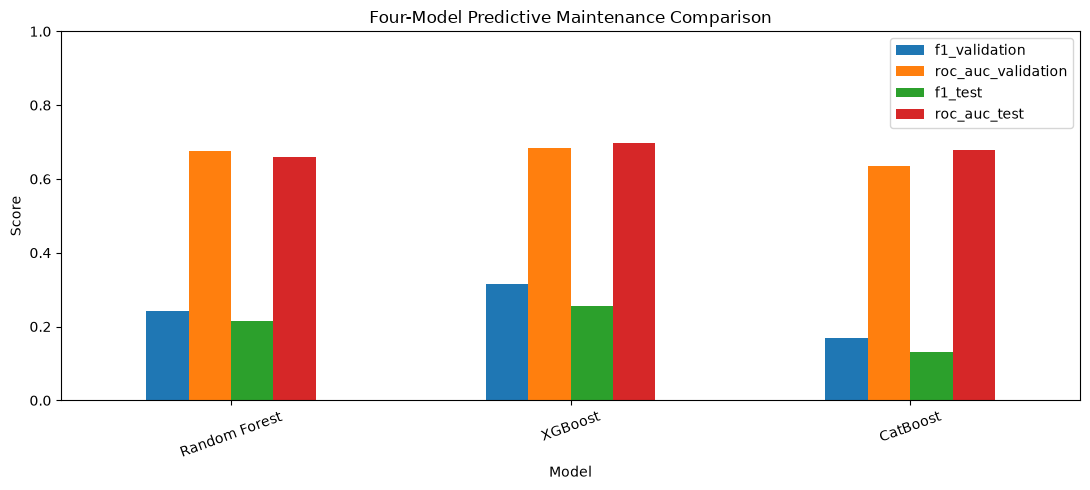

In [18]:
# Visual comparison

comparison_table.set_index("model")[
    [
        "f1_validation",
        "roc_auc_validation",
        "f1_test",
        "roc_auc_test"
    ]
].plot(
    kind="bar",
    figsize=(11, 5)
)

plt.title("Four-Model Predictive Maintenance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 11. Threshold Selection

A model outputs a probability such as:

> `0.82` → estimated probability of failure within the next 24 hours.

We then need a threshold to convert probability into an alert:

> probability ≥ threshold → maintenance alert.

A threshold of 0.50 is not automatically correct.

We select the model and threshold using the **validation set only**. The test set is not used for this decision.

For this challenge, we use **validation F1** as a neutral starting criterion because it balances precision and recall.

In a real facility, the threshold could instead be chosen using the business cost of:

- missed failures,
- unnecessary inspections,
- maintenance capacity,
- asset criticality.


In [19]:
# Select the model using validation F1 at the default threshold.
# This avoids using the test set to choose the final model.

selected_model_name = (
    validation_comparison
    .sort_values(
        ["f1", "roc_auc"],
        ascending=False
    )
    .iloc[0]["model"]
)

selected_model = models[selected_model_name]

print("Selected model for threshold tuning:", selected_model_name)


Selected model for threshold tuning: XGBoost


Selected threshold: 0.76


,threshold,precision,recall,f1
71,0.76,0.8263,0.2961,0.436


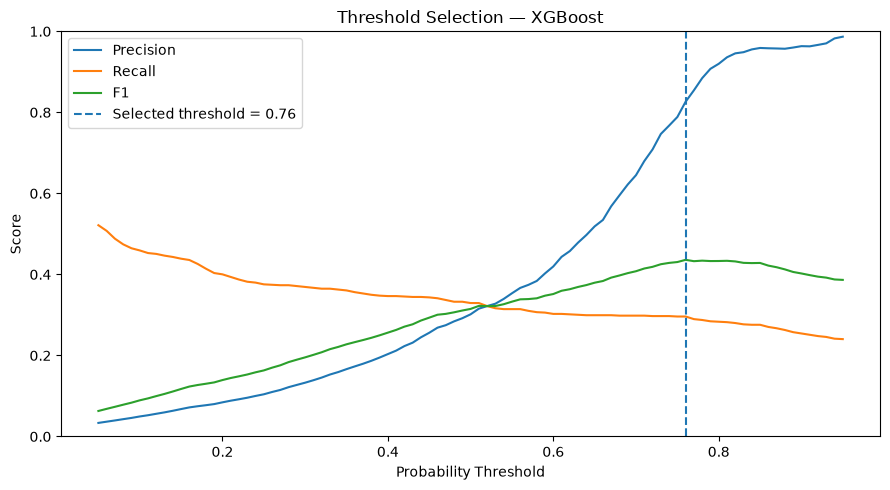

In [20]:
# Search for the best probability threshold on VALIDATION data only.

val_prob = get_probabilities(selected_model, X_val)

threshold_rows = []

for threshold in np.arange(0.05, 0.96, 0.01):
    val_pred = (val_prob >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "recall": recall_score(y_val, val_pred, zero_division=0),
        "f1": f1_score(y_val, val_pred, zero_division=0)
    })

threshold_results = pd.DataFrame(threshold_rows)

best_threshold_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

best_threshold = float(best_threshold_row["threshold"])

print(f"Selected threshold: {best_threshold:.2f}")
display(best_threshold_row.to_frame().T.round(4))
# Show the precision-recall trade-off across thresholds.

plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    label="F1"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Selected threshold = {best_threshold:.2f}"
)

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title(f"Threshold Selection — {selected_model_name}")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


## 12. Feature Importance

Feature importance answers:

> **Which variables are most useful to the selected model when predicting an upcoming failure?**

Instead of relying only on tree split importance, we use **permutation importance**.

The idea is simple:

1. Measure model performance.
2. Shuffle one feature.
3. Measure performance again.
4. A large performance decrease means that feature was useful.

We calculate it on the **validation set**, not the training set.


In [21]:
from sklearn.inspection import permutation_importance

# Permutation importance directly on the pipeline.
# This keeps preprocessing inside the model pipeline.

perm = permutation_importance(
    selected_model,
    X_val,
    y_val,
    scoring="f1",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
)

display(feature_importance.head(15).round(5))


,feature,importance_mean,importance_std
29,vibration_change_6h,0.08076,0.00274
12,vibration_mean_1h,0.07421,0.00413
13,vibration_max_1h,0.05389,0.00440
16,vibration_mean_12h,0.04044,0.00261
26,pressure_mean_1h,0.01916,0.00154
3,vibration,0.01866,0.00150
15,vibration_max_6h,0.00865,0.00228
27,pressure_mean_6h,0.00765,0.00107
2,pressure,0.00512,0.00140
28,vibration_change_1h,0.00152,0.00020


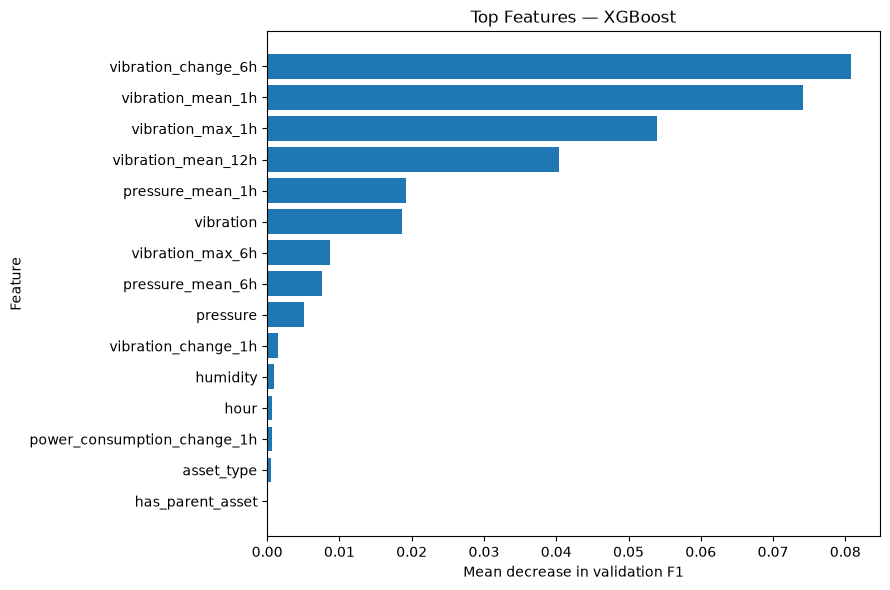

In [22]:
# Plot the top features.

top_features = feature_importance.head(15).sort_values("importance_mean")

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"],
    top_features["importance_mean"]
)

plt.xlabel("Mean decrease in validation F1")
plt.ylabel("Feature")
plt.title(f"Top Features — {selected_model_name}")
plt.tight_layout()
plt.show()


## 11A. Precision–Recall Curve

Because upcoming failures are rare, the precision–recall curve gives a more informative view of alert performance than ROC-AUC alone. Average Precision summarizes this curve across thresholds.


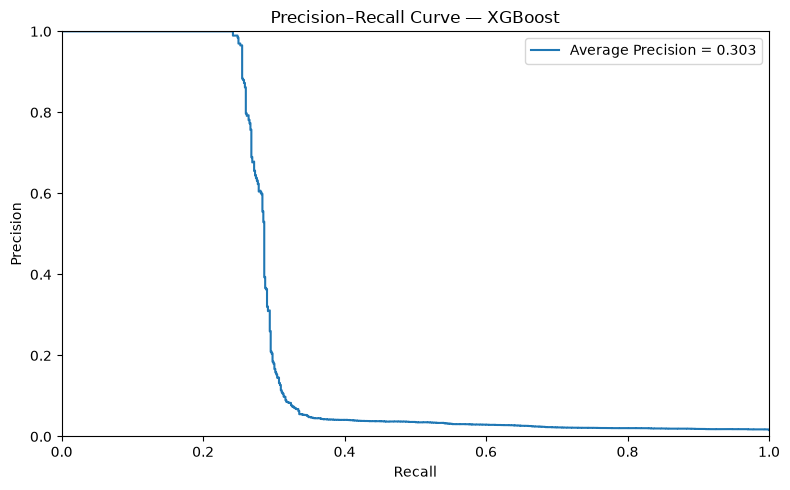

In [23]:
# Get predicted probabilities from the selected model
test_prob = selected_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import precision_recall_curve, average_precision_score

precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_prob)
test_ap = average_precision_score(y_test, test_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision_curve, label=f"Average Precision = {test_ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curve — {selected_model_name}")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


## 13. Error Analysis

Overall metrics do not tell us **where** the model fails.

We therefore examine:

- **False negatives:** actual upcoming failures that were missed.
- **False positives:** maintenance alerts where no failure occurred within 24 hours.
- Errors by asset type.
- Sensor conditions associated with missed failures.
- Missing sensor values in error cases.

For maintenance, false negatives are especially important because they represent failures that were not warned about.


In [24]:
# Final test predictions using the threshold selected on validation data.

test_prob = get_probabilities(selected_model, X_test)
final_test_pred = (test_prob >= best_threshold).astype(int)

final_metrics = {
    "model": selected_model_name,
    "threshold": best_threshold,
    "precision": precision_score(y_test, final_test_pred, zero_division=0),
    "recall": recall_score(y_test, final_test_pred, zero_division=0),
    "f1": f1_score(y_test, final_test_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, test_prob),
    "average_precision": average_precision_score(y_test, test_prob)
}

print("Final Test Metrics")
display(pd.DataFrame([final_metrics]).round(4))

print("Confusion Matrix")
display(pd.DataFrame(
    confusion_matrix(y_test, final_test_pred),
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
))

print("Classification Report")
print(
    classification_report(
        y_test,
        final_test_pred,
        digits=4,
        zero_division=0
    )
)


Final Test Metrics


,model,threshold,precision,recall,f1,roc_auc,average_precision
0,XGBoost,0.76,0.5677,0.2839,0.3785,0.6976,0.303


Confusion Matrix


,Predicted 0,Predicted 1
Actual 0,47416,166
Actual 1,550,218


Classification Report
              precision    recall  f1-score   support

           0     0.9885    0.9965    0.9925     47582
           1     0.5677    0.2839    0.3785       768

    accuracy                         0.9852     48350
   macro avg     0.7781    0.6402    0.6855     48350
weighted avg     0.9818    0.9852    0.9828     48350



In [25]:
# Build an error-analysis dataframe.

error_df = test_df.copy()

error_df["predicted_probability"] = test_prob
error_df["predicted_failure"] = final_test_pred

error_df["error_type"] = np.select(
    [
        (error_df[target_col] == 1) & (error_df["predicted_failure"] == 0),
        (error_df[target_col] == 0) & (error_df["predicted_failure"] == 1)
    ],
    [
        "False Negative",
        "False Positive"
    ],
    default="Correct"
)

print("Error counts")
display(
    error_df["error_type"]
    .value_counts()
    .rename_axis("error_type")
    .to_frame("count")
)


Error counts


,count
error_type,
Correct,47634
False Negative,550
False Positive,166


In [26]:
# Errors by asset type

error_by_asset_type = pd.crosstab(
    error_df["asset_type"],
    error_df["error_type"]
)

display(error_by_asset_type)


error_type,Correct,False Negative,False Positive
asset_type,,,
AHU,19099,122,125
Chiller,9535,133,0
Energy Meter,9538,130,0
Pump,9462,165,41


In [27]:
# Compare sensor conditions for false negatives and correctly detected failures.

failure_cases = error_df[error_df[target_col] == 1].copy()

if not failure_cases.empty:
    sensor_error_summary = (
        failure_cases
        .groupby("error_type")[
            [
                "temperature",
                "pressure",
                "vibration",
                "power_consumption"
            ]
        ]
        .mean()
        .round(3)
    )

    display(sensor_error_summary)
else:
    print("No positive failure cases were present in the test set.")


,temperature,pressure,vibration,power_consumption
error_type,,,,
Correct,24.121,1.632,0.382,36.008
False Negative,23.122,2.179,0.184,31.496


## 14. Business Insights

The model is intended to support maintenance teams rather than replace engineering judgement.

### Operational use

1. **Early warning**  
   Generate an alert when predicted failure probability crosses the selected threshold.

2. **Maintenance prioritization**  
   Sort assets by predicted failure probability.

3. **Condition-based inspection**  
   Use sensor trends such as vibration, power and temperature to investigate high-risk assets.

4. **Asset-specific monitoring**  
   Compare an asset with its own historical behaviour and with similar asset types.

5. **Alert management**  
   Track false positives and false negatives continuously so the alerting system remains useful.

### Important interpretation

A high predicted probability means:

> **the asset should be investigated**

It does **not** prove that a failure will happen.

Because this challenge uses synthetic data with deliberately introduced degradation before faults, strong performance should be treated as a proof of concept. A production system would require validation on real historical maintenance/failure data.


In [28]:
# Example operational alert table for the test period.

alerts = test_df[
    [
        "timestamp",
        "site_id",
        "building_id",
        "asset_id",
        "asset_type",
        "operating_mode",
        "vibration",
        "power_consumption",
        "temperature"
    ]
].copy()

alerts["failure_probability"] = test_prob
alerts["maintenance_alert"] = final_test_pred

alerts = alerts.sort_values(
    "failure_probability",
    ascending=False
)

print("Highest predicted maintenance risks")
display(alerts.head(20))


Highest predicted maintenance risks


,timestamp,site_id,building_id,asset_id,asset_type,operating_mode,vibration,power_consumption,temperature,failure_probability,maintenance_alert
41376,2026-03-17 15:00:00,SITE_01,BLDG_01,ASSET_005,Energy Meter,Cooling,0.509,95.918,23.467,0.999726,1
41375,2026-03-17 14:45:00,SITE_01,BLDG_01,ASSET_005,Energy Meter,Cooling,0.352,111.809,23.592,0.999704,1
41374,2026-03-17 14:30:00,SITE_01,BLDG_01,ASSET_005,Energy Meter,Cooling,0.432,117.052,23.815,0.999651,1
41377,2026-03-17 15:15:00,SITE_01,BLDG_01,ASSET_005,Energy Meter,Cooling,0.299,133.647,24.003,0.999609,1
41373,2026-03-17 14:15:00,SITE_01,BLDG_01,ASSET_005,Energy Meter,Cooling,0.352,116.976,24.711,0.999558,1
41372,2026-03-17 14:00:00,SITE_01,BLDG_01,ASSET_005,Energy Meter,Cooling,0.393,115.512,23.624,0.999543,1
41371,2026-03-17 13:45:00,SITE_01,BLDG_01,ASSET_005,Energy Meter,Cooling,0.457,112.513,25.102,0.999222,1
41370,2026-03-17 13:30:00,SITE_01,BLDG_01,ASSET_005,Energy Meter,Cooling,0.325,110.994,24.367,0.999183,1
41368,2026-03-17 13:00:00,SITE_01,BLDG_01,ASSET_005,Energy Meter,Cooling,0.358,110.767,24.443,0.999104,1
24787,2026-03-22 14:45:00,SITE_01,BLDG_01,ASSET_003,AHU,Cooling,0.384,18.731,27.257,0.998748,1


### Asset-Level Alert Summary

Telemetry predictions are made every 15 minutes, so one underlying failure can generate multiple consecutive alerts for the same asset. For operations, it is more useful to summarize risk at the asset level.


In [29]:
asset_alert_summary = (
    alerts.groupby(["asset_id", "asset_type", "building_id"])
    .agg(
        max_failure_probability=("failure_probability", "max"),
        mean_failure_probability=("failure_probability", "mean"),
        alert_count=("maintenance_alert", "sum"),
        observations=("maintenance_alert", "size")
    )
    .reset_index()
)

asset_alert_summary = asset_alert_summary.sort_values(
    "max_failure_probability", ascending=False
)

print("Highest-risk assets in the test period")
display(asset_alert_summary.head(20).round(4))


Highest-risk assets in the test period


,asset_id,asset_type,building_id,max_failure_probability,mean_failure_probability,alert_count,observations
4,ASSET_005,Energy Meter,BLDG_01,0.9997,0.0806,38,1608
2,ASSET_003,AHU,BLDG_01,0.9987,0.1158,36,1608
5,ASSET_006,Chiller,BLDG_02,0.9974,0.0615,59,1603
21,ASSET_022,AHU,BLDG_05,0.9972,0.0685,34,1608
19,ASSET_020,Energy Meter,BLDG_04,0.9960,0.0182,24,1608
8,ASSET_009,Pump,BLDG_02,0.9758,0.0455,39,1608
11,ASSET_012,AHU,BLDG_03,0.9196,0.3127,124,1613
23,ASSET_024,Pump,BLDG_05,0.8974,0.2220,21,1613
13,ASSET_014,Pump,BLDG_03,0.8891,0.1532,8,1613
22,ASSET_023,AHU,BLDG_05,0.7641,0.1663,1,1613


## 15.1 Limitations and Next Steps

- **Synthetic data:** degradation was deliberately introduced before some faults, so model performance should be treated as a proof of concept rather than real-world validation.
- **Repeated positive rows:** with 15-minute telemetry, several positive rows may correspond to the same underlying failure event; row-level metrics should therefore be interpreted as early-warning performance.
- **Recall:** the selected threshold is precision-oriented, so a substantial number of upcoming failures are still missed.
- **Asset-level evaluation:** future work should evaluate detection by unique failure event and measure lead time before the actual fault.
- **Production validation:** real maintenance history, failure severity, asset criticality and maintenance cost should be incorporated before deployment.


## 15. Final Conclusion

This predictive-maintenance workflow converts raw IoT telemetry into a **24-hour-ahead failure prediction problem**.

### What was implemented

- Engineered `failure_next_24h` from future fault events.
- Removed currently faulting assets from proactive prediction.
- Merged asset metadata.
- Created asset-age, time, rolling and trend features.
- Handled missing sensor values without training-data leakage.
- Used a chronological train/validation/test split.
- Handled class imbalance.
- Trained and compared:
  - Random Forest
  - XGBoost
  - CatBoost
- Selected the model using validation performance.
- Tuned the alert threshold using validation data.
- Evaluated the final model once on the unseen test period.
- Used permutation importance to interpret the selected model.
- Analysed false positives and false negatives.
- Converted the model output into an operational maintenance-alert table.



In [30]:
# 15. Save Predictive Maintenance Artifacts for the Dashboard

import joblib
import json

MODEL_DIR = OUTPUTS_DIR / "models" / "predictive_maintenance"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save the complete sklearn pipeline, including preprocessing.
joblib.dump(
    selected_model,
    MODEL_DIR / "predictive_maintenance_model.joblib"
)

# Save configuration needed by the dashboard/inference service.
model_config = {
    "model_name": selected_model_name,
    "threshold": float(best_threshold),
    "target": target_col,
    "numeric_features": list(numeric_features),
    "categorical_features": list(categorical_features),
    "random_state": RANDOM_STATE
}

with open(MODEL_DIR / "model_config.json", "w", encoding="utf-8") as f:
    json.dump(model_config, f, indent=2)

# Save final test predictions and useful operational summaries.
test_predictions = test_df[
    [
        "timestamp",
        "site_id",
        "building_id",
        "asset_id",
        "asset_type"
    ]
].copy()

test_predictions["actual_failure"] = y_test.values
test_predictions["failure_probability"] = test_prob
test_predictions["predicted_failure"] = final_test_pred

test_predictions.to_csv(
    MODEL_DIR / "test_predictions.csv",
    index=False
)

asset_alert_summary.to_csv(
    MODEL_DIR / "asset_alert_summary.csv",
    index=False
)

feature_importance.to_csv(
    MODEL_DIR / "feature_importance.csv",
    index=False
)

print("Saved predictive-maintenance artifacts to:", MODEL_DIR.resolve())

Saved predictive-maintenance artifacts to: C:\Users\priya\OneDrive\Documents\sem 10 INTERN\Challenge\Nectar Task\outputs\models\predictive_maintenance
